# Is the capacity of the nearest hospital dependent on the income of the people living in the city?
- capacity coef - sum of number of beds, number of doctors, number of nurses
- DPH,DNV,DPPO,DPFO,DPFO_srazkou,DPFO_zavisla_c,DPFO_zavisla_h - income features

We define the capacity coefficient of a hospital as the sum of the number of beds, doctors, and nurses. We will analyze whether there is a correlation between this capacity coefficient and various income features of the population in the city where the hospital is located. The income features we will consider include DPH (value-added tax), DNV (income from non-business activities), DPPO (personal income tax), DPFO (personal income tax for individuals), DPFO_srazkou (personal income tax withheld at source), DPFO_zavisla_c (personal income tax from dependent activities - corporate), and DPFO_zavisla_h (personal income tax from dependent activities - household). By examining these relationships, we aim to determine if higher income levels in a city are associated with greater hospital capacity.

We will normalize our capacity coefficient to 0-1 range for better interpretability by subtracting the minimum value and dividing by the range (max - min).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import squarify  # pip install squarify
import plotly.express as px
import seaborn as sns
import numpy as np
import statsmodels.api as sm
from patsy import cr
import plotly.graph_objects as go

Load the datasets

In [3]:
cities_df = pd.read_csv('../data/cities_with_all_data.csv')
#drop nans in income columns
income_cols = ['DPH', 'DNV', 'DPPO', 'DPFO', 'DPFO_srazkou', 'DPFO_zavisla_c', 'DPFO_zavisla_h']
cities_df = cities_df.dropna(subset=income_cols).copy()
hospitals_df = pd.read_csv('../data/nemocnice_kompletni.csv')

# calculate capacity coefficient for every hospital in hospitals_df
cols = ['Pocet_luzek', 'Pocet_lekaru', 'Pocet_sester']
for col in cols:
    hospitals_df[col] = pd.to_numeric(hospitals_df[col], errors='coerce')

hospitals_df_clean = hospitals_df.dropna(subset=cols).copy()

# capacity score
hospitals_df_clean['capacity_score'] = (
    hospitals_df_clean['Pocet_luzek'] +
    hospitals_df_clean['Pocet_lekaru'] +
    hospitals_df_clean['Pocet_sester']
)

# normalize
min_score = hospitals_df_clean['capacity_score'].min()
max_score = hospitals_df_clean['capacity_score'].max()
hospitals_df_clean['capacity_index'] = (hospitals_df_clean['capacity_score'] - min_score) / (max_score - min_score)


Lets see some of our data:

In [4]:
# show top 5 and bottom 5 hospitals by capacity_index
result = hospitals_df_clean[['Nazev', 'Pocet_luzek', 'Pocet_lekaru', 'Pocet_sester',
                             'capacity_index']].sort_values(by='capacity_index', ascending=False)

print("Top 5 hospitals by capacity index (TOP 5):")
print(result.head(5))

print("\nBottom 5 hospitals by capacity index (BOTTOM 5):")
print(result.tail(5))

#lets plot 3D scatter plot of hospitals with capacity_index as color

fig = px.scatter_3d(
    hospitals_df_clean,
    x='Pocet_luzek',
    y='Pocet_lekaru',
    z='Pocet_sester',
    color='capacity_index',
    hover_name='Nazev',  # Po najetí myší ukáže název nemocnice
    color_continuous_scale='Greens',
    title='3D Interaktivní mapa kapacit nemocnic'
)

fig.update_traces(marker=dict(size=5))
fig.show()

Top 5 hospitals by capacity index (TOP 5):
                                  Nazev  Pocet_luzek  Pocet_lekaru  \
6    Fakultní nemocnice Brno - Bohunice       1908.0         955.0   
64                      Nemocnice Motol       2199.0        1279.0   
5                    Fakultní nemocnice       1375.0         811.0   
9              Fakultní nemocnice Plzeň       1731.0         899.0   
136        Všeobecná fakultní nemocnice       1537.0         810.0   

     Pocet_sester  capacity_index  
6          2686.0        1.000000  
64         1989.0        0.984874  
5          2252.0        0.795056  
9          1598.0        0.756318  
136        1799.0        0.741192  

Bottom 5 hospitals by capacity index (BOTTOM 5):
                                         Nazev  Pocet_luzek  Pocet_lekaru  \
56                          Nemocnice Letovice        120.0          12.0   
102                    Nemocnice města Broumov        105.0           8.0   
30   Městská nemocnice s poliklinikou U

We susspect that economic factos might be strongly correlated. Lets check it.

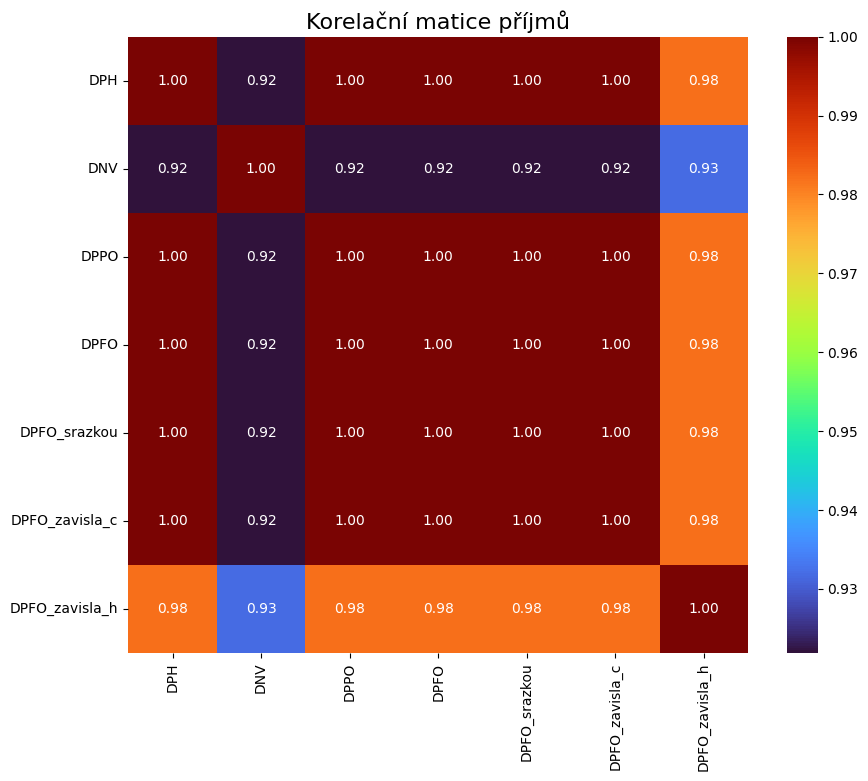

In [5]:
# check if income features are correlated, if yes, keep only the uncorrelated ones
income_cols = ['DPH', 'DNV', 'DPPO', 'DPFO',
               'DPFO_srazkou', 'DPFO_zavisla_c', 'DPFO_zavisla_h']
income_df = cities_df[income_cols].copy()
income_corr = income_df.corr()

# visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(income_corr, annot=True, cmap='turbo', fmt=".2f")
plt.title('Korelační matice příjmů', fontsize=16)
plt.show()


As expected all of the income features are highly correlated with each other (correlation coefficients above 0.8).
To avoid multicollinearity in the regression analysis, we will keep only one of these features, specifically 'DPFO' (personal income tax), for further analysis.

Lets analyze the relationship between hospital capacity and income feature 'DPFO'.

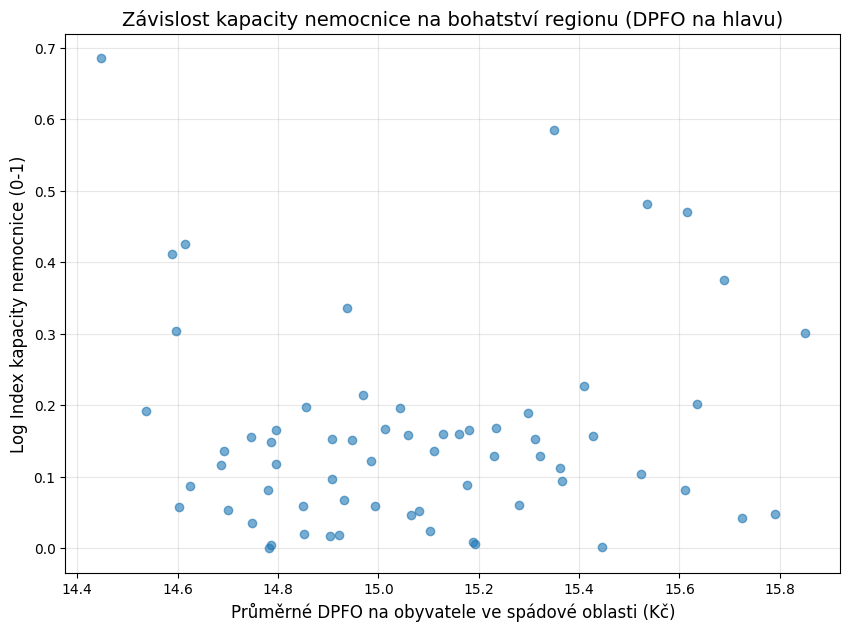

Korelační koeficient: 0.0271


In [6]:
# analyze the dependency of capacity_index on average income (DPFO) in catchment area
# calculate total DPFO and total population in the catchment area for each hospital

catchment_economy = cities_df.groupby('Nejblizsi_nemocnice').agg({
    'DPFO': 'sum',   # Celkový vybraný DPFO v oblasti
    'Total': 'sum'   # Celkový počet obyvatel v oblasti
}).reset_index()

# log-transform capacity_index
hospitals_df_clean['capacity_index'] = hospitals_df_clean['capacity_index'].copy()
hospitals_df_clean['capacity_index'] = np.log1p(
    hospitals_df_clean['capacity_index'])

# high_capacity_index = hospitals_df_clean['capacity_index'].quantile(0.95)
# hospitals_df_clean = hospitals_df_clean[(hospitals_df_clean['capacity_index'] <= high_capacity_index)]

# DPFO na hlavu (bohatství regionu)
catchment_economy['dpfo_per_capita'] = catchment_economy['DPFO'] / \
    catchment_economy['Total']
final_df = pd.merge(catchment_economy, hospitals_df_clean,
                    left_on='Nejblizsi_nemocnice', right_on='Nazev')
final_df = final_df.dropna(subset=['dpfo_per_capita', 'capacity_index'])
low = final_df['dpfo_per_capita'].quantile(0.05)
high = final_df['dpfo_per_capita'].quantile(0.95)
filtered_df = final_df[
    (final_df['dpfo_per_capita'] >= low) &
    (final_df['dpfo_per_capita'] <= high)
]

plt.figure(figsize=(10, 7))
plt.plot(filtered_df['dpfo_per_capita'],
         filtered_df['capacity_index'], 'o', alpha=0.6)
plt.title(
    'Závislost kapacity nemocnice na bohatství regionu (DPFO na hlavu)', fontsize=14)
plt.xlabel('Průměrné DPFO na obyvatele ve spádové oblasti (Kč)', fontsize=12)
plt.ylabel('Log Index kapacity nemocnice (0-1)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

corr = filtered_df['dpfo_per_capita'].corr(filtered_df['capacity_index'])
print(f"Korelační koeficient: {corr:.4f}")

From the plot above and the correlation coefficient of 0.0271 we can susspect that there is no significant correlation between the capacity of the nearest hospital and the income of the people living in the city. However, to confirm this observation, we will perform a linear regression analysis and also some other models to see if there is any hidden relationship.

TEST LINEARITY


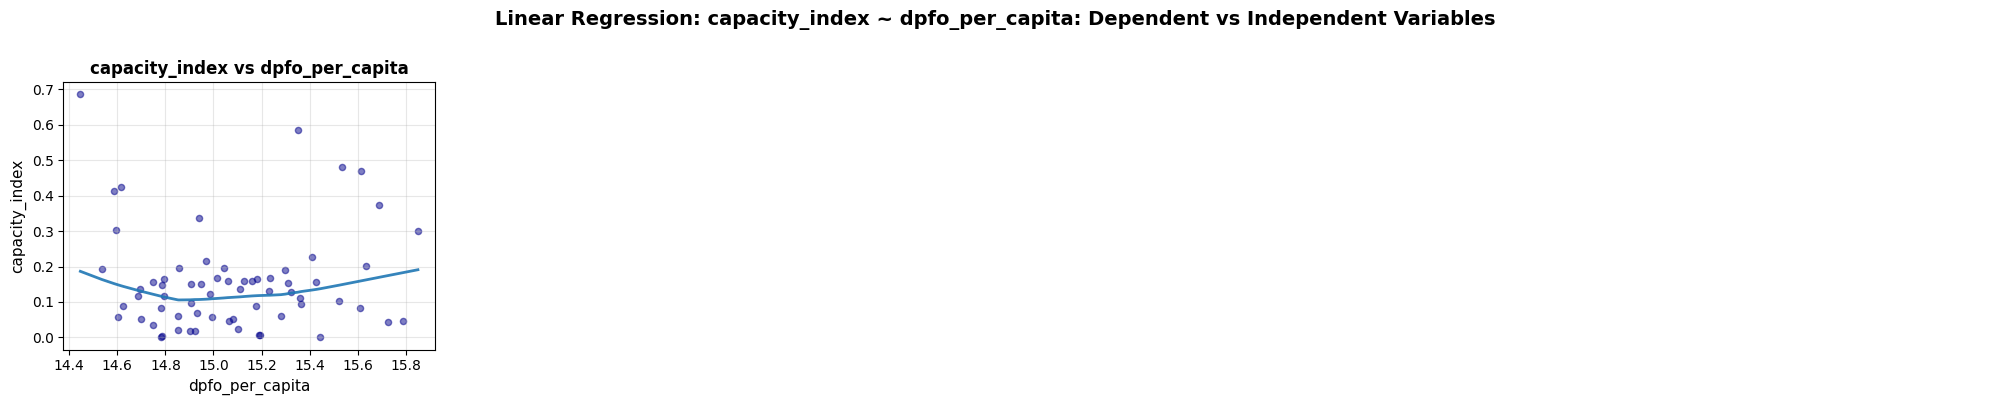

Interpretation:
  - LOWESS line shows the trend between each feature and target
  - Linear trend = good; curved pattern = potential non-linearity



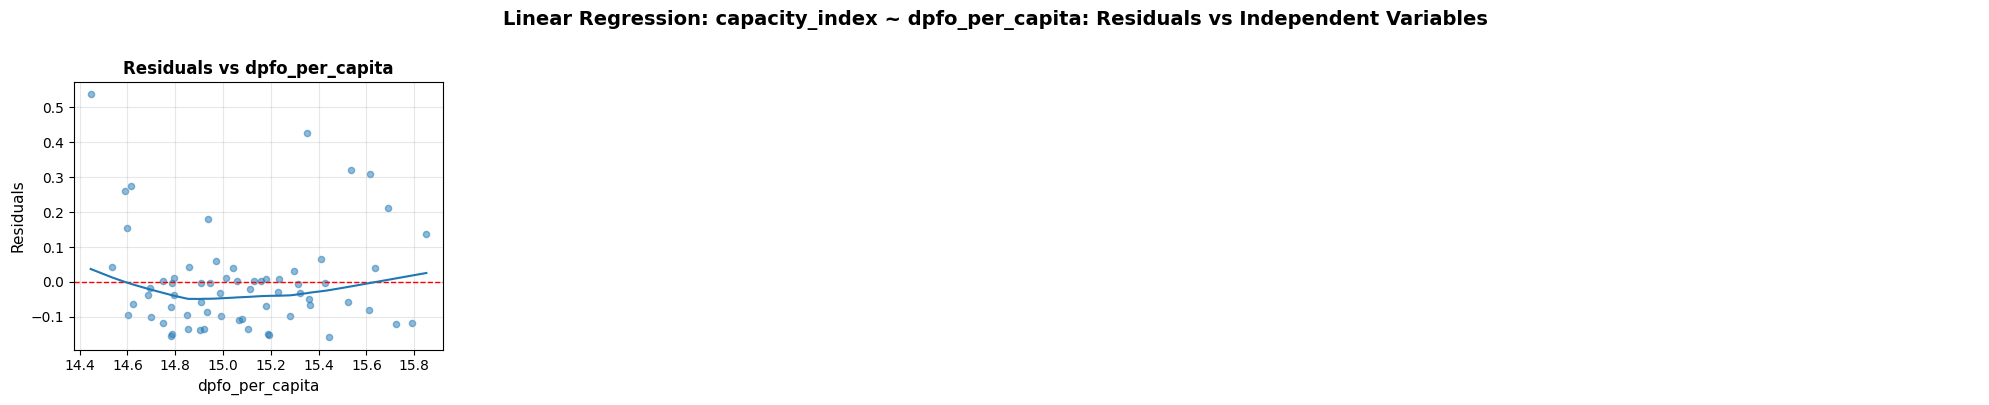

Interpretation:
  - Points should be randomly scattered around y=0; no patterns
  - Curves = non-linearity; funnel = heteroscedasticity
------------------------------------------------
TEST HOMOSCEDASTICITY
Breusch–Pagan LM p-value for Linear Regression: capacity_index ~ dpfo_per_capita: 0.8395 (LM stat=0.350)
------------------------------------------------
TEST INDEPENDENCE OF ERRORS
Durbin–Watson statistic for Linear Regression: capacity_index ~ dpfo_per_capita: 1.386
Ljung–Box test results for Linear Regression: capacity_index ~ dpfo_per_capita (lags [10, 20, 40]):
      lb_stat  lb_pvalue
10  10.334970   0.411613
20  14.333513   0.813191
40  45.768004   0.245089


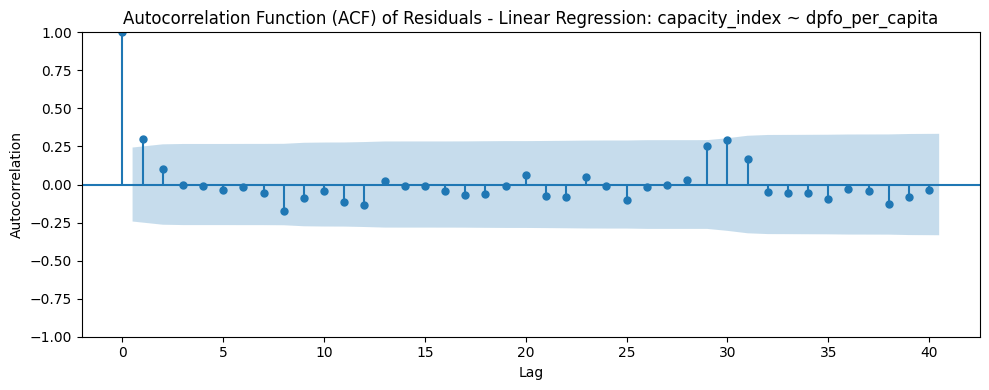

------------------------------------------------
TEST NORMALITY OF ERRORS


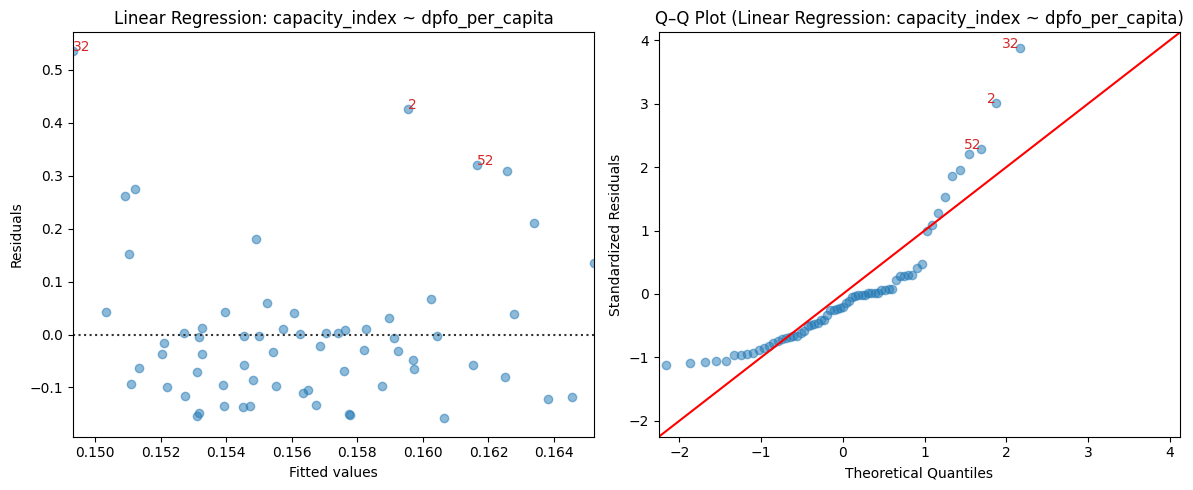

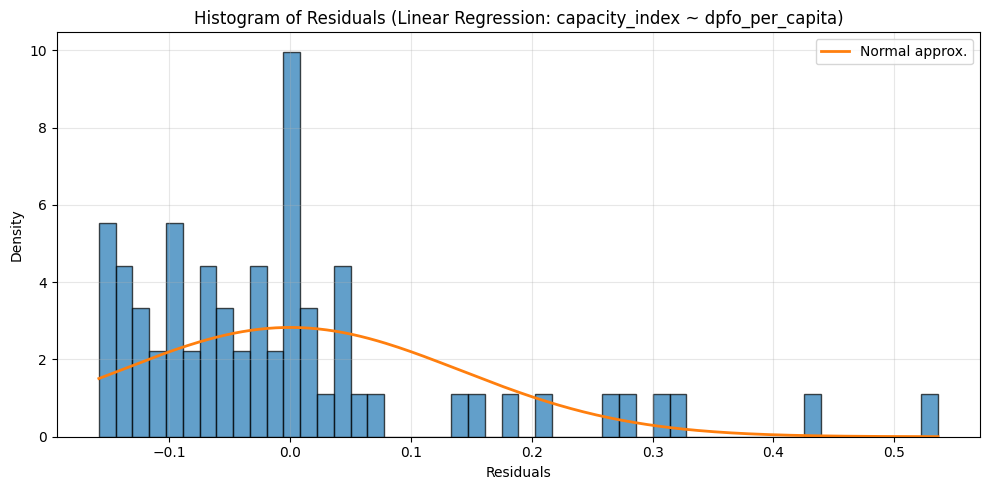

Shapiro–Wilk test for Linear Regression: capacity_index ~ dpfo_per_capita: W=0.8278, p-value=3.145e-07
------------------------------------------------
TEST MULTICOLLINEARITY


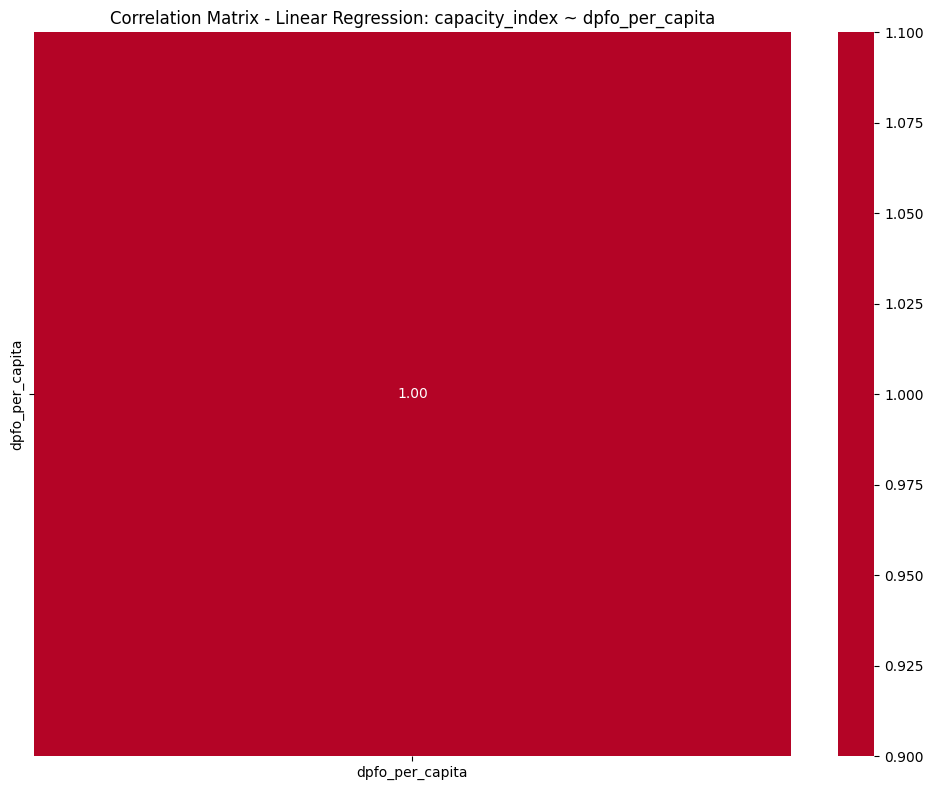

Variance Inflation Factor (VIF):
          Features  VIF Factor
1  dpfo_per_capita        1.00
0            const     1989.27
------------------------------------------------


In [8]:
lin_model = sm.OLS(
    filtered_df['capacity_index'],
    sm.add_constant(filtered_df['dpfo_per_capita'])
).fit()

from lin_reg_utils import perform_all_tests
perform_all_tests(lin_model, filtered_df, ['dpfo_per_capita'], 'Linear Regression: capacity_index ~ dpfo_per_capita', y_col='capacity_index')

Looking at assumptions, we see that the model violates some of them:
1) Linearity - <span style="color:Green;">Holds</span>
    - there is a linear trend 
2) Independence of errors - <span style="color:green;">Holds</span> 
    - based on Durbin-Watson test, Ljung-Box test and ACF plot of residuals we can say that there is no autocorrelation (Durbin-Watson is 1.386, Ljung-Box p-values are all higly above 0.05)
3) Normality of residuals - <span style="color:red;">Violates</span>
    - based on Q-Q plot, histogram and Shapiro-Wilk test we can say that the residuals are not normally distributed (Shapiro-Wilk p-value is < 0.05)
4) Homoscedacity - <span style="color:green;">Holds</span>
    - based on Breusch-Pagan test we can say that there is Homoscedacity (p-value is 0.8395 > 0.05)
5) Absence of multicollinearity - <span style="color:Green;">Holds</span>
    - there is only one feature in the model so there is no multicollinearity

Lets power transform the target variable to see if we can fix the normality of residuals issue. 
We will use square root transformation.

TEST LINEARITY


/var/folders/yl/lszvz30d1qncdyky_jyr_5y40000gn/T/ipykernel_72270/42226383.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



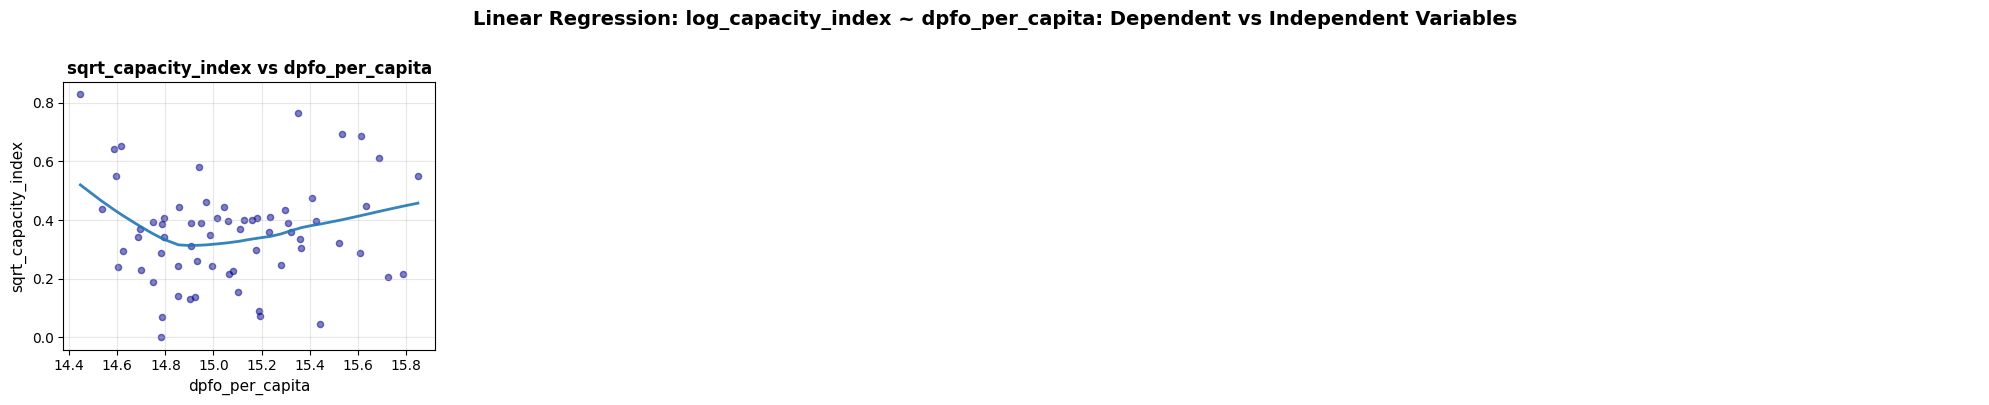

Interpretation:
  - LOWESS line shows the trend between each feature and target
  - Linear trend = good; curved pattern = potential non-linearity



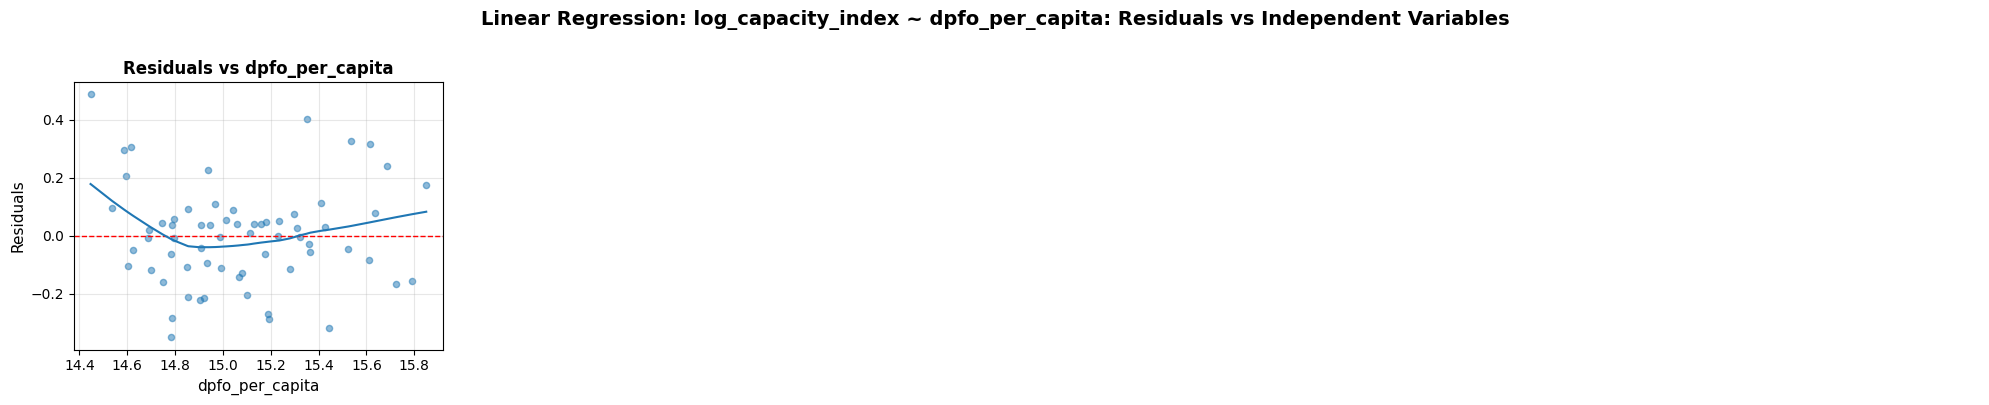

Interpretation:
  - Points should be randomly scattered around y=0; no patterns
  - Curves = non-linearity; funnel = heteroscedasticity
------------------------------------------------
TEST HOMOSCEDASTICITY
Breusch–Pagan LM p-value for Linear Regression: log_capacity_index ~ dpfo_per_capita: 0.8749 (LM stat=0.267)
------------------------------------------------
TEST INDEPENDENCE OF ERRORS
Durbin–Watson statistic for Linear Regression: log_capacity_index ~ dpfo_per_capita: 1.505
Ljung–Box test results for Linear Regression: log_capacity_index ~ dpfo_per_capita (lags [10, 20, 40]):
      lb_stat  lb_pvalue
10  12.017336   0.283898
20  16.000421   0.716598
40  42.956361   0.345721


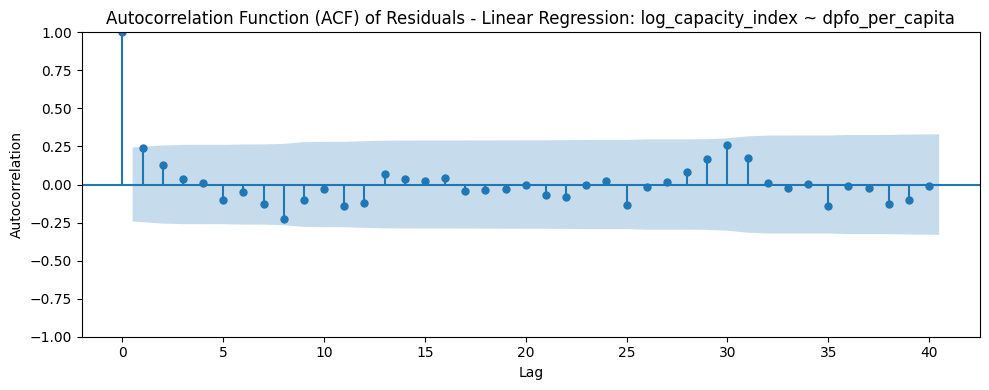

------------------------------------------------
TEST NORMALITY OF ERRORS


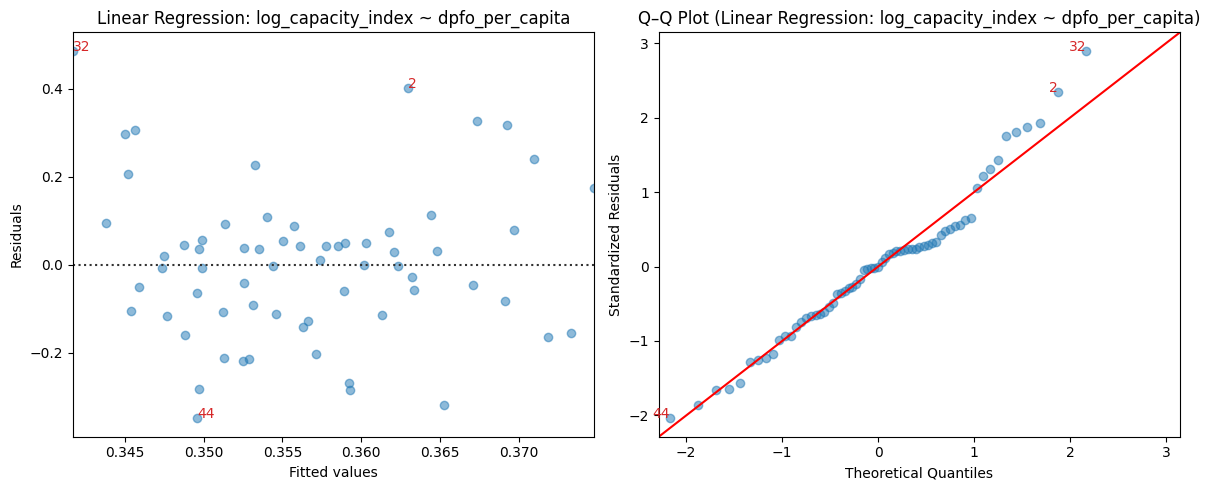

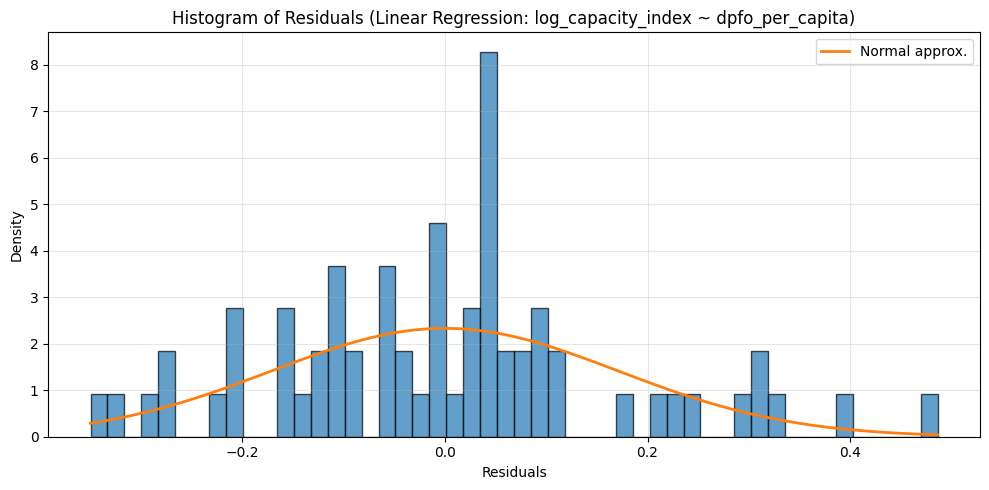

Shapiro–Wilk test for Linear Regression: log_capacity_index ~ dpfo_per_capita: W=0.9723, p-value=0.1517
------------------------------------------------
TEST MULTICOLLINEARITY


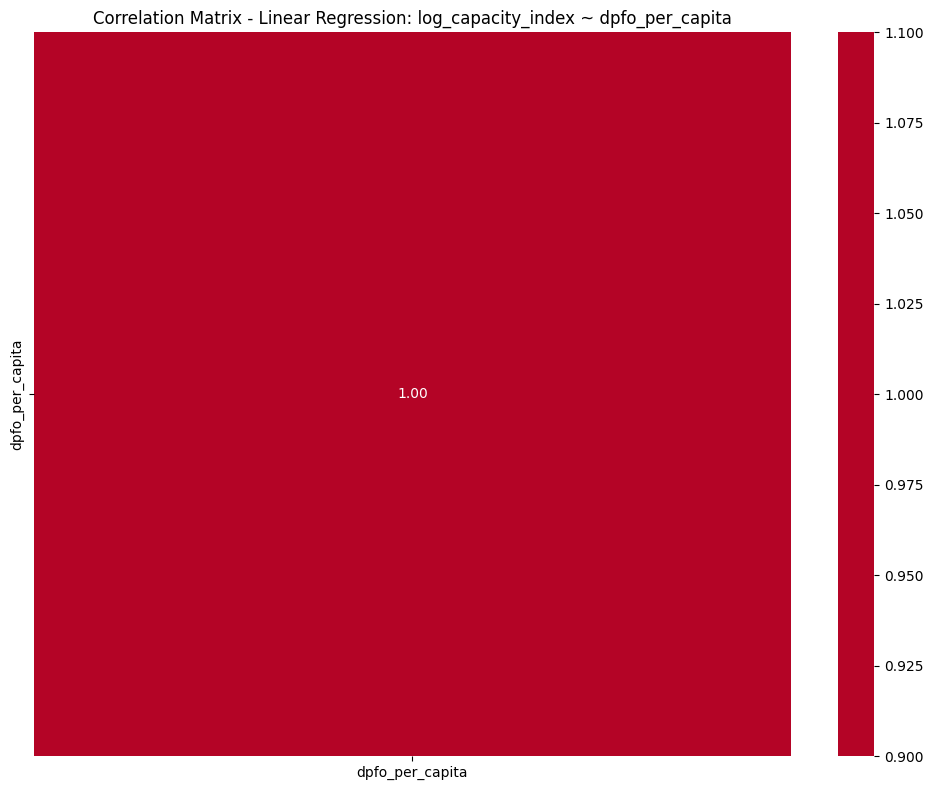

Variance Inflation Factor (VIF):
          Features  VIF Factor
1  dpfo_per_capita        1.00
0            const     1989.27
------------------------------------------------


In [9]:
filtered_df['sqrt_capacity_index'] = filtered_df['capacity_index'] ** 0.5
lin_model = sm.OLS(
    filtered_df['sqrt_capacity_index'],
    sm.add_constant(filtered_df['dpfo_per_capita'])
).fit()
from lin_reg_utils import perform_all_tests
perform_all_tests(lin_model, filtered_df, ['dpfo_per_capita'], 'Linear Regression: log_capacity_index ~ dpfo_per_capita', y_col='sqrt_capacity_index')

Looking at assumptions, we see that the model violates some of them:
1) Linearity - <span style="color:Green;">Holds</span>
    - there is a linear trend 
2) Independence of errors - <span style="color:green;">Holds</span> 
    - based on Durbin-Watson test, Ljung-Box test and ACF plot of residuals we can say that there is no autocorrelation (Durbin-Watson is 1.505, Ljung-Box p-values are all higly above 0.05)
3) Normality of residuals - <span style="color:green;">Holds</span>
    - based on Q-Q plot, histogram and Shapiro-Wilk test we can say that the residuals are now normally distributed (Shapiro-Wilk p-value is 0.1517)
4) Homoscedacity - <span style="color:green;">Holds</span>
    - based on Breusch-Pagan test we can say that there is Homoscedacity (p-value is 0.8749 > 0.05)
5) Absence of multicollinearity - <span style="color:Green;">Holds</span>
    - there is only one feature in the model so there is no multicollinearity

                             OLS Regression Results                            
Dep. Variable:     sqrt_capacity_index   R-squared:                       0.002
Model:                             OLS   Adj. R-squared:                 -0.014
Method:                  Least Squares   F-statistic:                    0.1364
Date:                 Sat, 13 Dec 2025   Prob (F-statistic):              0.713
Time:                         15:06:03   Log-Likelihood:                 22.512
No. Observations:                   65   AIC:                            -41.02
Df Residuals:                       63   BIC:                            -36.68
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0014      

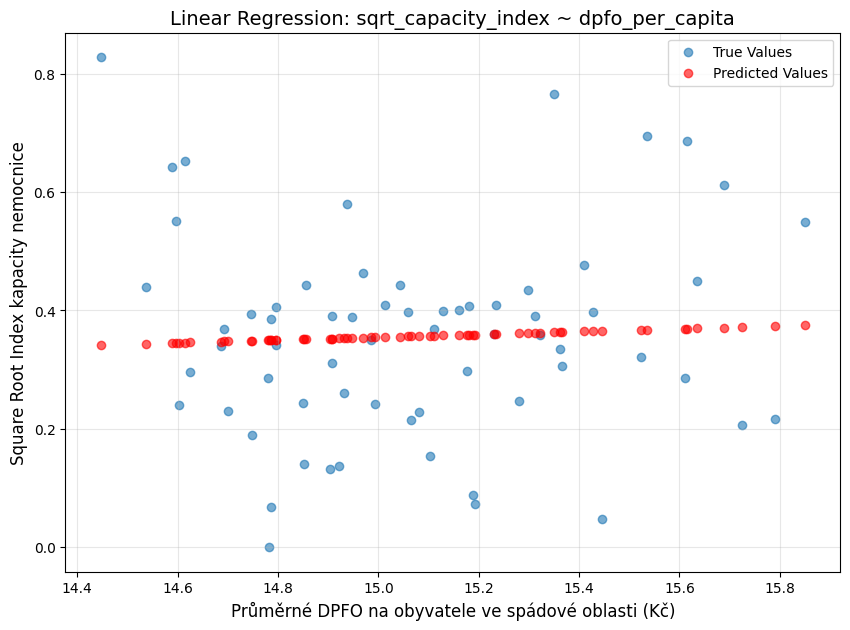

In [10]:
print(lin_model.summary())
#plot
plt.figure(figsize=(10, 7))
y_true = filtered_df['sqrt_capacity_index']
y_pred = lin_model.predict(sm.add_constant(filtered_df['dpfo_per_capita']))
plt.scatter(filtered_df['dpfo_per_capita'], y_true, label='True Values', alpha=0.6)
plt.scatter(filtered_df['dpfo_per_capita'], y_pred, color='red', label='Predicted Values', alpha=0.6)
plt.title('Linear Regression: sqrt_capacity_index ~ dpfo_per_capita', fontsize=14)
plt.xlabel('Průměrné DPFO na obyvatele ve spádové oblasti (Kč)', fontsize=12)
plt.ylabel('Square Root Index kapacity nemocnice', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)


The linear regression analysis indicates that there is no significant relationship between hospital capacity (sqrt hospital index) and income levels in the city. The coefficient for 'dpfo_per_capita' is positive but very close to zero (0.0236) this suggests that changes in income have a negligible effect on hospital capacity. Additionally, the R-squared value is also small 0.002 meaning that only 0.2% of the variance in hospital capacity can be explained by income levels.
At least the slope is positive so higher income is associated with higher hospital capacity, but the effect is minimal.

Lets try quadratic regression to see if there is any non-linear relationship between income and hospital capacity.

In [17]:
# fit quadratic model
model_quadratic = sm.OLS.from_formula(
    'capacity_index ~ dpfo_per_capita + I(dpfo_per_capita**2)', data=filtered_df).fit()


                            OLS Regression Results                            
Dep. Variable:         capacity_index   R-squared:                       0.148
Model:                            OLS   Adj. R-squared:                  0.120
Method:                 Least Squares   F-statistic:                     5.382
Date:                Sat, 13 Dec 2025   Prob (F-statistic):            0.00699
Time:                        15:37:39   Log-Likelihood:                 40.253
No. Observations:                  65   AIC:                            -74.51
Df Residuals:                      62   BIC:                            -67.98
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

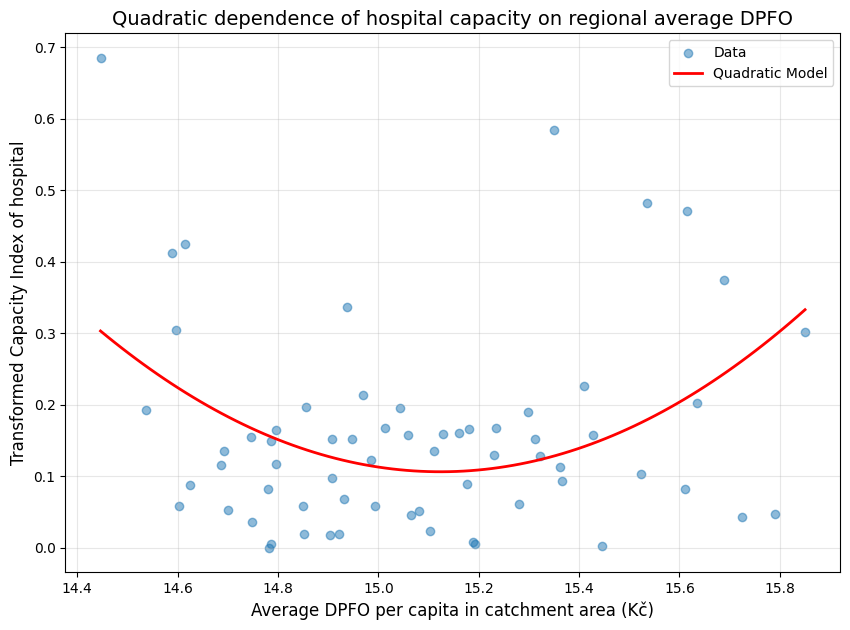

In [21]:
print(model_quadratic.summary())

plt.figure(figsize=(10, 7))
plt.scatter(filtered_df['dpfo_per_capita'],
            filtered_df['capacity_index'], alpha=0.5, label='Data')
x_range = np.linspace(filtered_df['dpfo_per_capita'].min(
), filtered_df['dpfo_per_capita'].max(), 100)
prediction_df = pd.DataFrame({'dpfo_per_capita': x_range})
y_pred = model_quadratic.predict(prediction_df)
plt.plot(x_range, y_pred, color='red', linewidth=2, label='Quadratic Model')
plt.title(
    'Quadratic dependence of hospital capacity on regional average DPFO', fontsize=14)
plt.xlabel('Average DPFO per capita in catchment area (Kč)', fontsize=12)
plt.ylabel('Transformed Capacity Index of hospital', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
#save
plt.savefig('../results/income_capacity_quadratic_model.pdf')

plt.show()


Quadratic model is much better than linear one (R2 0.148 vs 0.002). However, the relationship is still very weak. The coefficient for the squared term is positive (0.4294). This means that for lower DPFO with increases in income, the hospital capacity increases slowly. However, as income continues to rise, the rate of increase in hospital capacity accelerates. 

We think that this is due to the state politics. In lower income areas, there might be a baseline level of hospital capacity that is maintained regardless of income levels. However, in higher income areas, there may be more resources available for healthcare infrastructure, leading to a more pronounced increase in hospital capacity as income rises.

Lets also test spline regression to see if we can get better results.

In [13]:
# fit spline model
model_spline = sm.OLS.from_formula(
    'capacity_index ~ cr(dpfo_per_capita, df=6)', data=filtered_df).fit()
print(model_spline.summary())

x_range = np.linspace(filtered_df['dpfo_per_capita'].min(
), filtered_df['dpfo_per_capita'].max(), 200)
prediction_df = pd.DataFrame({'dpfo_per_capita': x_range})
y_pred_spline = model_spline.predict(prediction_df)
fig = px.scatter(
    filtered_df,
    x='dpfo_per_capita',
    y='capacity_index',
    hover_name='Nazev',
    hover_data=['Total'],
    title='Interaktivní Spline model: Kapacita nemocnic vs Bohatství regionu',
    opacity=0.6,
    labels={
        'dpfo_per_capita': 'DPFO na obyvatele (Kč)', 'capacity_index': 'Log Index kapacity'}
)
fig.add_trace(
    go.Scatter(
        x=x_range,
        y=y_pred_spline,
        mode='lines',
        name='Spline Model (df=5)',
        line=dict(color='red', width=3)
    )
)
fig.show()

                            OLS Regression Results                            
Dep. Variable:         capacity_index   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.298
Method:                 Least Squares   F-statistic:                     6.444
Date:                Sat, 13 Dec 2025   Prob (F-statistic):           7.69e-05
Time:                        15:06:03   Log-Likelihood:                 49.211
No. Observations:                  65   AIC:                            -86.42
Df Residuals:                      59   BIC:                            -73.38
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

Spline model improves the R2 to 0.35 which means that 35% of the variance in hospital capacity can be explained by income levels. The spline regression captures more complex, non-linear relationships between income and hospital capacity. The plot shows that at lower income levels, increases in income lead to decreases in hospital capacity, which could be due to various socio-economic factors. However, as income levels rise beyond a certain point, the trend reverses and higher income is associated with increased hospital capacity. This suggests that there may be threshold effects or other underlying dynamics at play that influence how income impacts hospital resources.

# Conclusion

We think that income does have an effect on hospital capacity, but the relationship is complex and non-linear. Other factors beyond income likely play a significant role in determining hospital capacity in different areas.
